In [14]:
# ============================================================
# PHASE 7 - Setup (MySQL 9.x compatible)
# ============================================================

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import warnings
warnings.filterwarnings('ignore')

load_dotenv(r"C:\Users\yipch\ecommerce-analytics-portfolio\.env")

DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "3306")
DB_USER = os.getenv("DB_USER", "root")
DB_PASS = os.getenv("DB_PASSWORD", "")
DB_NAME = os.getenv("DB_NAME", "ecommerce_analytics")

# ✅ mysql-connector-python works with MySQL 9.x natively
conn_str = (
    f"mysql+mysqlconnector://{DB_USER}:{DB_PASS}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)
engine = create_engine(
    conn_str,
    echo=False,
    connect_args={"connection_timeout": 30}
)

# Test connection
try:
    with engine.connect() as conn:
        result = conn.execute(text("SELECT COUNT(*) FROM fact_events"))
        rows   = result.fetchone()[0]
        print(f"✅ Connected to MySQL 9.6!")
        print(f"   fact_events rows : {rows:,}")
except Exception as e:
    print(f"❌ Connection failed: {e}")

BASE_DIR   = r"C:\Users\yipch\ecommerce-analytics-portfolio"
FIG_DIR    = os.path.join(BASE_DIR, "reports", "figures")
EXPORT_DIR = os.path.join(BASE_DIR, "data", "exports")

def save_fig(fig, filename):
    path = os.path.join(FIG_DIR, filename)
    fig.write_html(path)
    print(f"  💾 Saved: reports/figures/{filename}")

def read_sql(query):
    """Run SQL → DataFrame with all Decimal types cast to float."""
    with engine.connect() as conn:
        result = conn.execute(text(query))
        rows   = result.fetchall()
        cols   = result.keys()
        df_out = pd.DataFrame(rows, columns=cols)
        # ✅ Fix: try converting each column, skip if it fails
        for col in df_out.columns:
            try:
                df_out[col] = pd.to_numeric(df_out[col])
            except (ValueError, TypeError):
                pass  # leave non-numeric columns as-is
        return df_out

print("\n✅ Setup complete. Starting Advanced Analytics.")

✅ Connected to MySQL 9.6!
   fact_events rows : 1,605,102

✅ Setup complete. Starting Advanced Analytics.


In [3]:
# ============================================================
# STEP 2A - Build RFM Base Table
# R = Recency   → days since last purchase (lower = better)
# F = Frequency → number of purchases
# M = Monetary  → total spend
# ============================================================

df_rfm_base = read_sql("""
    SELECT
        f.user_id,
        MAX(d.full_date)                        AS last_purchase_date,
        COUNT(*)                                AS frequency,
        ROUND(SUM(f.revenue), 2)                AS monetary
    FROM fact_events f
    JOIN dim_date d ON f.date_id = d.date_id
    WHERE f.event_type = 'purchase'
    GROUP BY f.user_id
    HAVING monetary > 0
""")

# Recency = days from last purchase to snapshot date
snapshot_date = pd.to_datetime(df_rfm_base["last_purchase_date"].max())
df_rfm_base["last_purchase_date"] = pd.to_datetime(df_rfm_base["last_purchase_date"])
df_rfm_base["recency"] = (
    snapshot_date - df_rfm_base["last_purchase_date"]
).dt.days

print(f"✅ RFM base built")
print(f"   Buyers tracked : {df_rfm_base.shape[0]:,}")
print(f"   Snapshot date  : {snapshot_date.date()}")
print(f"\n📊 RFM Stats:")
print(df_rfm_base[["recency","frequency","monetary"]].describe().round(2).to_string())

✅ RFM base built
   Buyers tracked : 11,698
   Snapshot date  : 2019-11-30

📊 RFM Stats:
        recency  frequency
count  11698.00   11698.00
mean      27.67       2.10
std       17.47       3.21
min        0.00       1.00
25%       13.00       1.00
50%       27.00       1.00
75%       43.00       2.00
max       60.00     111.00


In [5]:
# ============================================================
# STEP 2B - Score RFM (FIXED: cast Decimal → float)
# ============================================================

df_rfm = df_rfm_base.copy()

# ✅ Fix: convert all numeric columns from Decimal to float
df_rfm["recency"]   = df_rfm["recency"].astype(float)
df_rfm["frequency"] = df_rfm["frequency"].astype(float)
df_rfm["monetary"]  = df_rfm["monetary"].astype(float)

def score_column(series, reverse=False):
    """Assign 1–5 score. reverse=True means lower value = higher score."""
    labels = [5,4,3,2,1] if reverse else [1,2,3,4,5]
    try:
        return pd.qcut(series, q=5, labels=labels, duplicates="drop")
    except ValueError:
        return pd.cut(series, bins=5, labels=labels, duplicates="drop")

df_rfm["R_score"] = score_column(df_rfm["recency"],   reverse=True).astype(int)
df_rfm["F_score"] = score_column(df_rfm["frequency"], reverse=False).astype(int)
df_rfm["M_score"] = score_column(df_rfm["monetary"],  reverse=False).astype(int)

# Combined RFM score
df_rfm["RFM_score"] = (
    df_rfm["R_score"].astype(str) +
    df_rfm["F_score"].astype(str) +
    df_rfm["M_score"].astype(str)
)
df_rfm["RFM_total"] = df_rfm["R_score"] + df_rfm["F_score"] + df_rfm["M_score"]

print("✅ RFM scores assigned (1=worst, 5=best)")
print(f"\n   Score distribution:")
print(df_rfm[["R_score","F_score","M_score","RFM_total"]].describe().round(2).to_string())

✅ RFM scores assigned (1=worst, 5=best)

   Score distribution:
        R_score   F_score   M_score  RFM_total
count  11698.00  11698.00  11698.00   11698.00
mean       3.04      1.00      3.00       7.04
std        1.41      0.09      1.41       2.07
min        1.00      1.00      1.00       3.00
25%        2.00      1.00      2.00       6.00
50%        3.00      1.00      3.00       7.00
75%        4.00      1.00      4.00       9.00
max        5.00      5.00      5.00      14.00


In [6]:
# ============================================================
# STEP 2C - RFM Segmentation
# Business-readable segments based on R + F scores
# ============================================================

def rfm_segment(row):
    r = row["R_score"]
    f = row["F_score"]
    m = row["M_score"]

    if r >= 4 and f >= 4 and m >= 4:
        return "🏆 Champions"
    elif r >= 3 and f >= 3 and m >= 3:
        return "💛 Loyal Customers"
    elif r >= 4 and f <= 2:
        return "🌱 Promising"
    elif r >= 3 and f >= 2 and m >= 3:
        return "⚠️  At Risk"
    elif r <= 2 and f >= 3 and m >= 3:
        return "😴 Cant Lose Them"
    elif r <= 2 and f <= 2 and m <= 2:
        return "💀 Lost"
    elif r >= 4 and f == 1:
        return "🆕 New Customers"
    else:
        return "😐 Needs Attention"

df_rfm["segment"] = df_rfm.apply(rfm_segment, axis=1)

# Segment summary
seg_summary = (
    df_rfm.groupby("segment")
    .agg(
        users           = ("user_id",   "count"),
        avg_recency     = ("recency",   "mean"),
        avg_frequency   = ("frequency", "mean"),
        avg_monetary    = ("monetary",  "mean"),
        total_revenue   = ("monetary",  "sum"),
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)
seg_summary["avg_recency"]   = seg_summary["avg_recency"].round(1)
seg_summary["avg_frequency"] = seg_summary["avg_frequency"].round(2)
seg_summary["avg_monetary"]  = seg_summary["avg_monetary"].round(2)
seg_summary["total_revenue"] = seg_summary["total_revenue"].round(2)
seg_summary["revenue_share"] = (
    seg_summary["total_revenue"] /
    seg_summary["total_revenue"].sum() * 100
).round(1)

print("📊 RFM Segment Summary:")
print(seg_summary.to_string(index=False))

📊 RFM Segment Summary:
          segment  users  avg_recency  avg_frequency  avg_monetary  total_revenue  revenue_share
😐 Needs Attention   5087         37.3           2.13        729.68     3711863.36           50.0
      🌱 Promising   4723          9.6           2.26        685.02     3235350.91           43.6
           💀 Lost   1870         47.1           1.20         88.21      164950.41            2.2
💛 Loyal Customers      6         15.2          67.50      27374.42      164246.50            2.2
      ⚠️  At Risk     10         31.3          31.10      11884.14      118841.39            1.6
      🏆 Champions      1          0.0          88.00      11094.36       11094.36            0.1
 😴 Cant Lose Them      1         38.0          50.00      10607.96       10607.96            0.1


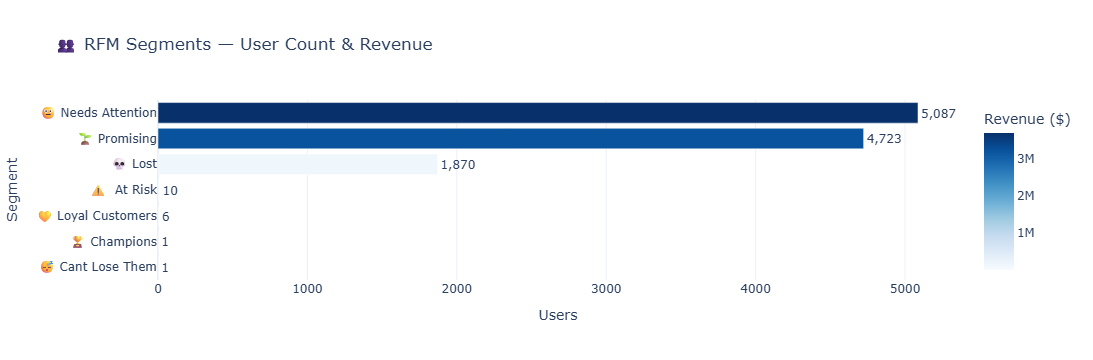

  💾 Saved: reports/figures/09_rfm_segments_bar.html


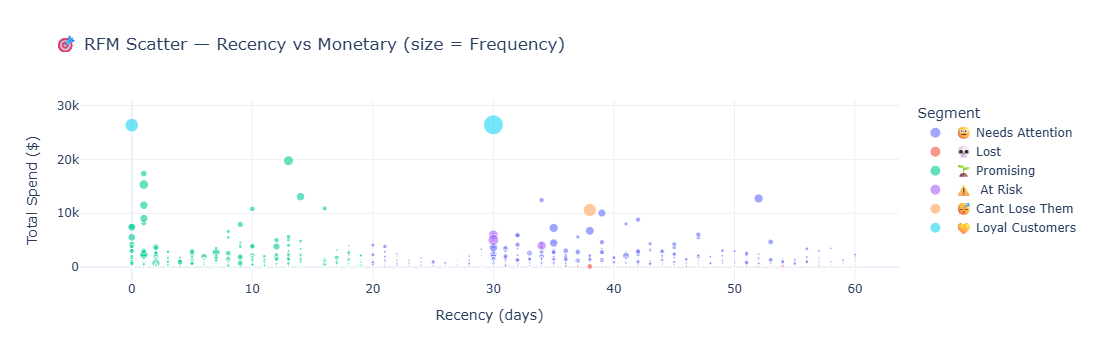

  💾 Saved: reports/figures/10_rfm_scatter.html


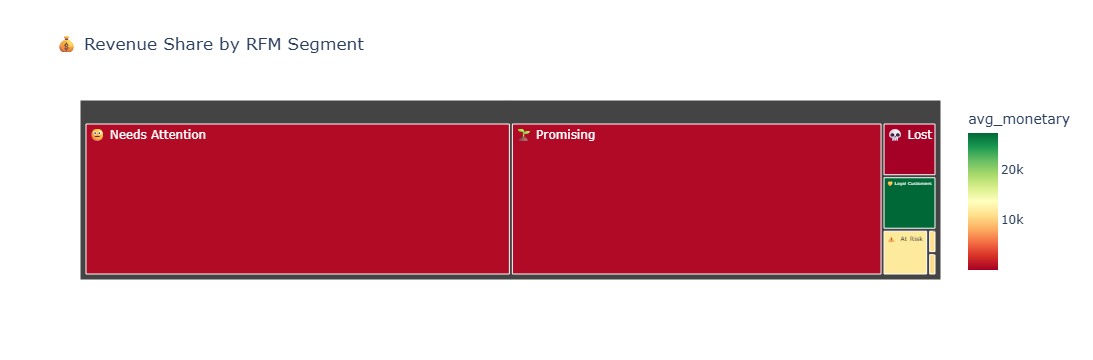

  💾 Saved: reports/figures/11_rfm_treemap.html


In [7]:
# ============================================================
# STEP 2D - Plot RFM Segments
# ============================================================

# ── Chart 1: Users per segment ──
fig1 = px.bar(
    seg_summary.sort_values("users", ascending=True),
    x           = "users",
    y           = "segment",
    orientation = "h",
    color       = "total_revenue",
    color_continuous_scale = "Blues",
    text        = "users",
    title       = "👥 RFM Segments — User Count & Revenue",
    labels      = {"users":"Users", "segment":"Segment",
                   "total_revenue":"Revenue ($)"},
)
fig1.update_traces(texttemplate="%{text:,}", textposition="outside")
fig1.update_layout(template="plotly_white")
fig1.show()
save_fig(fig1, "09_rfm_segments_bar.html")

# ── Chart 2: RFM scatter (Recency vs Monetary, size=Frequency) ──
fig2 = px.scatter(
    df_rfm.sample(min(3000, len(df_rfm)), random_state=42),
    x       = "recency",
    y       = "monetary",
    color   = "segment",
    size    = "frequency",
    opacity = 0.6,
    title   = "🎯 RFM Scatter — Recency vs Monetary (size = Frequency)",
    labels  = {
        "recency"   : "Recency (days)",
        "monetary"  : "Total Spend ($)",
        "frequency" : "Purchase Frequency",
        "segment"   : "Segment",
    },
)
fig2.update_layout(template="plotly_white")
fig2.show()
save_fig(fig2, "10_rfm_scatter.html")

# ── Chart 3: Revenue share treemap ──
fig3 = px.treemap(
    seg_summary,
    path    = ["segment"],
    values  = "total_revenue",
    color   = "avg_monetary",
    color_continuous_scale = "RdYlGn",
    title   = "💰 Revenue Share by RFM Segment",
)
fig3.update_layout(template="plotly_white")
fig3.show()
save_fig(fig3, "11_rfm_treemap.html")

In [10]:
# ============================================================
# STEP 3A - Detailed Funnel by Category (FIXED)
# ============================================================

df_funnel_cat = read_sql("""
    SELECT
        p.category_l1,
        SUM(CASE WHEN f.event_type='view'
                 THEN 1 ELSE 0 END)             AS views,
        SUM(CASE WHEN f.event_type='cart'
                 THEN 1 ELSE 0 END)             AS carts,
        SUM(CASE WHEN f.event_type='purchase'
                 THEN 1 ELSE 0 END)             AS purchases,
        ROUND(SUM(CASE WHEN f.event_type='cart'
                 THEN 1 ELSE 0 END) * 100.0 /
              NULLIF(SUM(CASE WHEN f.event_type='view'
                 THEN 1 ELSE 0 END),0), 2)      AS view_to_cart_pct,
        ROUND(SUM(CASE WHEN f.event_type='purchase'
                 THEN 1 ELSE 0 END) * 100.0 /
              NULLIF(SUM(CASE WHEN f.event_type='cart'
                 THEN 1 ELSE 0 END),0), 2)      AS cart_to_purchase_pct,
        ROUND(SUM(CASE WHEN f.event_type='purchase'
                 THEN 1 ELSE 0 END) * 100.0 /
              NULLIF(SUM(CASE WHEN f.event_type='view'
                 THEN 1 ELSE 0 END),0), 2)      AS overall_conv_pct
    FROM fact_events f
    JOIN dim_products p ON f.product_id = p.product_id
    WHERE p.category_l1 != 'unknown'
    GROUP BY p.category_l1
    HAVING views >= 100
    ORDER BY overall_conv_pct DESC
    LIMIT 12
""")

# ✅ Fix: cast all Decimal/object columns to float
for col in ["views","carts","purchases",
            "view_to_cart_pct","cart_to_purchase_pct","overall_conv_pct"]:
    df_funnel_cat[col] = pd.to_numeric(df_funnel_cat[col], errors="coerce")

print("📊 Funnel by Category:")
print(df_funnel_cat[[
    "category_l1","views","carts","purchases",
    "view_to_cart_pct","cart_to_purchase_pct","overall_conv_pct"
]].to_string(index=False))

📊 Funnel by Category:
 category_l1    views   carts  purchases  view_to_cart_pct  cart_to_purchase_pct  overall_conv_pct
 electronics 543327.0 31344.0    13585.0              5.77                 43.34              2.50
  stationery    267.0    10.0        4.0              3.75                 40.00              1.50
    medicine    539.0    21.0        8.0              3.90                 38.10              1.48
  appliances 186156.0  5847.0     2570.0              3.14                 43.95              1.38
        auto  31103.0   679.0      335.0              2.18                 49.34              1.08
        kids  18736.0   322.0      182.0              1.72                 56.52              0.97
   computers  96171.0  2053.0      922.0              2.13                 44.91              0.96
construction  24517.0   689.0      228.0              2.81                 33.09              0.93
   furniture  46831.0   598.0      297.0              1.28                 49.67       

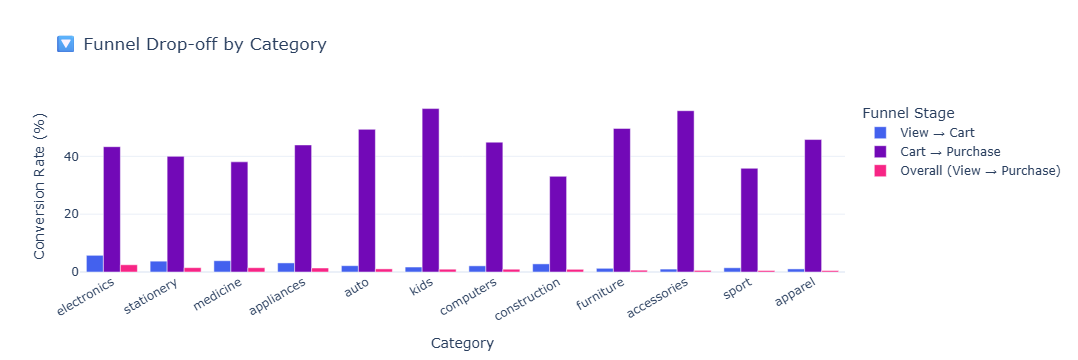

  💾 Saved: reports/figures/12_funnel_by_category.html

🔍 Key Insight:
   Best  cart→purchase : kids  (56.52%)
   Worst cart→purchase : construction  (33.09%)
   💡 'construction' has high cart abandon — investigate pricing or UX


In [11]:
# ============================================================
# STEP 3B - Plot Funnel Drop-off by Category
# ============================================================

# Melt for grouped bar chart
df_melt = df_funnel_cat.melt(
    id_vars    = "category_l1",
    value_vars = ["view_to_cart_pct","cart_to_purchase_pct","overall_conv_pct"],
    var_name   = "funnel_stage",
    value_name = "conversion_pct",
)

stage_labels = {
    "view_to_cart_pct"       : "View → Cart",
    "cart_to_purchase_pct"   : "Cart → Purchase",
    "overall_conv_pct"       : "Overall (View → Purchase)",
}
df_melt["funnel_stage"] = df_melt["funnel_stage"].map(stage_labels)

fig4 = px.bar(
    df_melt,
    x        = "category_l1",
    y        = "conversion_pct",
    color    = "funnel_stage",
    barmode  = "group",
    title    = "🔽 Funnel Drop-off by Category",
    labels   = {
        "category_l1"    : "Category",
        "conversion_pct" : "Conversion Rate (%)",
        "funnel_stage"   : "Funnel Stage",
    },
    color_discrete_sequence = ["#4361ee","#7209b7","#f72585"],
)
fig4.update_layout(
    template = "plotly_white",
    xaxis    = dict(tickangle=-30),
)
fig4.show()
save_fig(fig4, "12_funnel_by_category.html")

# Key insight
worst = df_funnel_cat.nsmallest(1, "cart_to_purchase_pct").iloc[0]
best  = df_funnel_cat.nlargest(1,  "cart_to_purchase_pct").iloc[0]
print(f"\n🔍 Key Insight:")
print(f"   Best  cart→purchase : {best['category_l1']}  ({best['cart_to_purchase_pct']}%)")
print(f"   Worst cart→purchase : {worst['category_l1']}  ({worst['cart_to_purchase_pct']}%)")
print(f"   💡 '{worst['category_l1']}' has high cart abandon — investigate pricing or UX")

📊 Converted vs Non-Converted Sessions:
   session_type  session_count  avg_events  avg_duration_min  avg_products_viewed
    ✅ Converted          20964        7.99             10.56                 2.93
❌ Not Converted         320562        4.48             18.00                 3.00


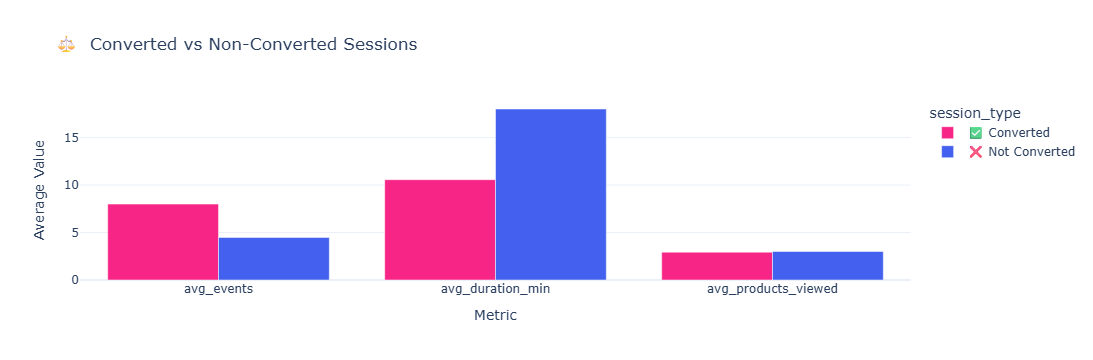

  💾 Saved: reports/figures/13_session_depth.html


In [15]:
# ============================================================
# STEP 3C - Session-level funnel depth
# How many events before a purchase?
# ============================================================

df_session = read_sql("""
    SELECT
        s.session_converted,
        ROUND(AVG(s.session_event_count), 2)    AS avg_events,
        ROUND(AVG(s.session_duration_min), 2)   AS avg_duration_min,
        ROUND(AVG(s.unique_products), 2)        AS avg_products_viewed,
        ROUND(AVG(s.session_revenue), 2)        AS avg_session_revenue,
        COUNT(*)                                AS session_count
    FROM dim_sessions s
    GROUP BY s.session_converted
""")

df_session["session_type"] = df_session["session_converted"].map(
    {1: "✅ Converted", 0: "❌ Not Converted"}
)

print("📊 Converted vs Non-Converted Sessions:")
print(df_session[[
    "session_type","session_count","avg_events",
    "avg_duration_min","avg_products_viewed"
]].to_string(index=False))

fig5 = px.bar(
    df_session.melt(
        id_vars    = "session_type",
        value_vars = ["avg_events","avg_duration_min","avg_products_viewed"],
        var_name   = "metric",
        value_name = "value",
    ),
    x        = "metric",
    y        = "value",
    color    = "session_type",
    barmode  = "group",
    title    = "⚖️  Converted vs Non-Converted Sessions",
    labels   = {"metric":"Metric","value":"Average Value"},
    color_discrete_sequence = ["#f72585","#4361ee"],
)
fig5.update_layout(template="plotly_white")
fig5.show()
save_fig(fig5, "13_session_depth.html")

In [16]:
# ============================================================
# STEP 4A - Pareto: Which products drive 80% of revenue?
# ============================================================

df_pareto = read_sql("""
    SELECT
        product_id,
        brand,
        category_l1,
        purchases,
        ROUND(total_revenue, 2) AS total_revenue
    FROM vw_product_performance
    WHERE purchases >= 1
    ORDER BY total_revenue DESC
""")

# Cumulative revenue %
total_rev = df_pareto["total_revenue"].sum()
df_pareto["cum_revenue"]     = df_pareto["total_revenue"].cumsum()
df_pareto["cum_revenue_pct"] = (df_pareto["cum_revenue"] / total_rev * 100).round(2)
df_pareto["product_rank"]    = range(1, len(df_pareto) + 1)
df_pareto["product_pct"]     = (
    df_pareto["product_rank"] / len(df_pareto) * 100
).round(2)

# Find 80% threshold
pareto_threshold = df_pareto[df_pareto["cum_revenue_pct"] <= 80]
n_products_80    = len(pareto_threshold)
pct_products_80  = n_products_80 / len(df_pareto) * 100

print(f"✅ Pareto Analysis:")
print(f"   Total products  : {len(df_pareto):,}")
print(f"   Total revenue   : ${total_rev:,.2f}")
print(f"\n   📊 Pareto Rule:")
print(f"   {n_products_80:,} products ({pct_products_80:.1f}%) "
      f"→ drive 80% of revenue")
print(f"\n   Top 10 products by revenue:")
print(df_pareto[["product_id","brand","category_l1",
                 "purchases","total_revenue","cum_revenue_pct"]
               ].head(10).to_string(index=False))

✅ Pareto Analysis:
   Total products  : 6,453
   Total revenue   : $7,416,954.89

   📊 Pareto Rule:
   488 products (7.6%) → drive 80% of revenue

   Top 10 products by revenue:
 product_id   brand category_l1  purchases  total_revenue  cum_revenue_pct
    1005115   apple electronics      505.0      480968.22             6.48
    1005105   apple electronics      201.0      275361.66            10.20
    1005135   apple electronics      121.0      203939.28            12.95
    1004249   apple electronics      259.0      195031.07            15.58
    1004767 samsung electronics      647.0      160350.19            17.74
    1002544   apple electronics      337.0      158799.89            19.88
    1004856 samsung electronics      871.0      112641.41            21.40
    1004870 samsung electronics      349.0       99557.74            22.74
    1002524   apple electronics      182.0       98026.19            24.06
    1005116   apple electronics       96.0       97828.68            25.

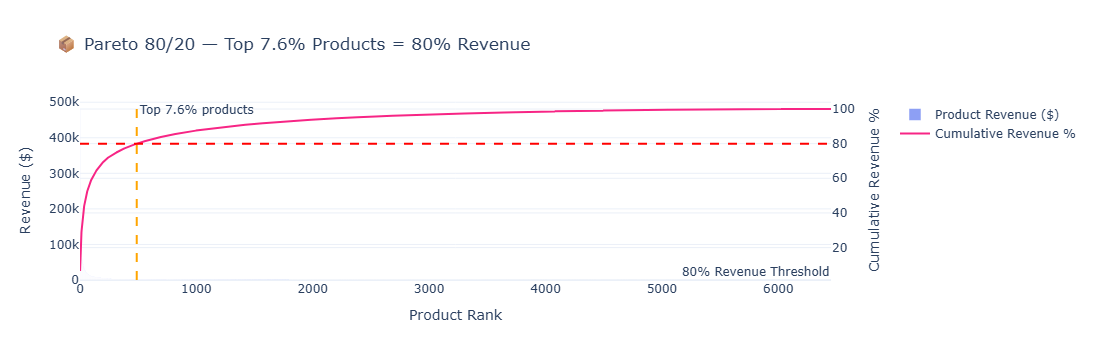

  💾 Saved: reports/figures/14_pareto_80_20.html


In [17]:
# ============================================================
# STEP 4B - Plot Pareto Chart
# ============================================================

fig6 = make_subplots(specs=[[{"secondary_y": True}]])

# Bar: individual product revenue
fig6.add_trace(
    go.Bar(
        x            = df_pareto["product_rank"],
        y            = df_pareto["total_revenue"],
        name         = "Product Revenue ($)",
        marker_color = "#4361ee",
        opacity      = 0.6,
    ),
    secondary_y = False,
)

# Line: cumulative revenue %
fig6.add_trace(
    go.Scatter(
        x    = df_pareto["product_rank"],
        y    = df_pareto["cum_revenue_pct"],
        name = "Cumulative Revenue %",
        mode = "lines",
        line = dict(color="#f72585", width=2),
    ),
    secondary_y = True,
)

# 80% threshold line
fig6.add_hline(
    y           = 80,
    line_dash   = "dash",
    line_color  = "red",
    secondary_y = True,
    annotation_text = "80% Revenue Threshold",
)

# 20% vertical line
fig6.add_vline(
    x           = n_products_80,
    line_dash   = "dash",
    line_color  = "orange",
    annotation_text = f"Top {pct_products_80:.1f}% products",
)

fig6.update_layout(
    title     = f"📦 Pareto 80/20 — Top {pct_products_80:.1f}% Products = 80% Revenue",
    template  = "plotly_white",
    hovermode = "x unified",
    xaxis     = dict(title="Product Rank"),
)
fig6.update_yaxes(title_text="Revenue ($)",           secondary_y=False)
fig6.update_yaxes(title_text="Cumulative Revenue %",  secondary_y=True)

fig6.show()
save_fig(fig6, "14_pareto_80_20.html")

📊 Brand Pareto:
   6 brands (0.2%) → 80% of revenue

   Top 10 brands:
  brand    revenue  purchases  cum_rev_pct  brand_rank
  apple 3452603.80     4472.0        48.52           1
samsung 1551972.69     5612.0        70.33           2
 xiaomi  315076.42     1932.0        74.76           3
 huawei  128228.49      615.0        76.56           4
     lg  122805.83      323.0        78.29           5
   acer  101101.79      199.0        79.71           6
lucente   98394.30      377.0        81.09           7
   oppo   96030.47      409.0        82.44           8
   sony   80938.11      240.0        83.58           9
   asus   63202.65      110.0        84.47          10


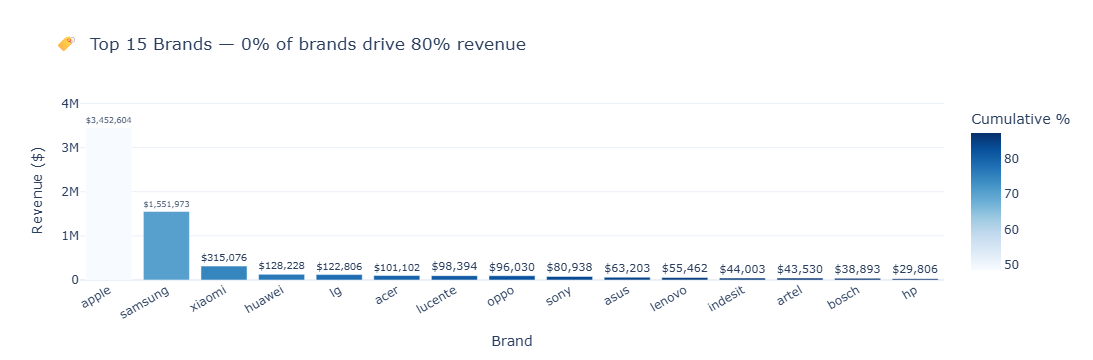

  💾 Saved: reports/figures/15_brand_pareto.html


In [18]:
# ============================================================
# STEP 4C - Pareto by Brand (which brands follow the rule?)
# ============================================================

df_brand_pareto = read_sql("""
    SELECT
        brand,
        ROUND(SUM(total_revenue), 2) AS revenue,
        SUM(purchases)               AS purchases
    FROM vw_product_performance
    WHERE brand != 'unknown'
    GROUP BY brand
    ORDER BY revenue DESC
""")

df_brand_pareto["cum_rev_pct"] = (
    df_brand_pareto["revenue"].cumsum() /
    df_brand_pareto["revenue"].sum() * 100
).round(2)
df_brand_pareto["brand_rank"] = range(1, len(df_brand_pareto) + 1)

n_brands_80   = len(df_brand_pareto[df_brand_pareto["cum_rev_pct"] <= 80])
pct_brands_80 = n_brands_80 / len(df_brand_pareto) * 100

print(f"📊 Brand Pareto:")
print(f"   {n_brands_80} brands ({pct_brands_80:.1f}%) → 80% of revenue")
print(f"\n   Top 10 brands:")
print(df_brand_pareto.head(10).to_string(index=False))

fig7 = px.bar(
    df_brand_pareto.head(15),
    x     = "brand",
    y     = "revenue",
    color = "cum_rev_pct",
    color_continuous_scale = "Blues",
    title = f"🏷️  Top 15 Brands — {pct_brands_80:.0f}% of brands drive 80% revenue",
    text  = "revenue",
    labels = {"revenue":"Revenue ($)","brand":"Brand",
               "cum_rev_pct":"Cumulative %"},
)
fig7.update_traces(texttemplate="$%{text:,.0f}", textposition="outside")
fig7.update_layout(
    template = "plotly_white",
    xaxis    = dict(tickangle=-30),
)
fig7.show()
save_fig(fig7, "15_brand_pareto.html")

In [19]:
# ============================================================
# STEP 5 - Save all advanced analytics outputs
# ============================================================

# Save RFM table (used in Power BI + Streamlit)
rfm_path = os.path.join(EXPORT_DIR, "analysis_rfm.csv")
df_rfm.to_csv(rfm_path, index=False)

# Save Pareto table
pareto_path = os.path.join(EXPORT_DIR, "analysis_pareto.csv")
df_pareto.to_csv(pareto_path, index=False)

# Save funnel by category
funnel_path = os.path.join(EXPORT_DIR, "analysis_funnel_category.csv")
df_funnel_cat.to_csv(funnel_path, index=False)

# Save segment summary
seg_path = os.path.join(EXPORT_DIR, "analysis_rfm_segments.csv")
seg_summary.to_csv(seg_path, index=False)

print("💾 Advanced analytics outputs saved:\n")
for path in [rfm_path, pareto_path, funnel_path, seg_path]:
    rows = pd.read_csv(path).shape[0]
    size = os.path.getsize(path) / 1024
    print(f"  ✅ {os.path.basename(path):<35} {rows:>6} rows  {size:.1f} KB")

print(f"\n🎯 15 charts total saved to reports/figures/")
print(f"   Open any .html file in your browser to view!")

# Final champion segment insight
champions = seg_summary[
    seg_summary["segment"].str.contains("Champions")
]
if not champions.empty:
    c = champions.iloc[0]
    print(f"\n🏆 Champions Segment Insight:")
    print(f"   Users          : {int(c['users']):,}")
    print(f"   Avg Spend      : ${c['avg_monetary']:,.2f}")
    print(f"   Revenue Share  : {c['revenue_share']:.1f}%")
    print(f"   💡 These users deserve a VIP loyalty program")

💾 Advanced analytics outputs saved:

  ✅ analysis_rfm.csv                     11698 rows  761.1 KB
  ✅ analysis_pareto.csv                   6453 rows  449.1 KB
  ✅ analysis_funnel_category.csv            12 rows  0.6 KB
  ✅ analysis_rfm_segments.csv                7 rows  0.4 KB

🎯 15 charts total saved to reports/figures/
   Open any .html file in your browser to view!

🏆 Champions Segment Insight:
   Users          : 1
   Avg Spend      : $11,094.36
   Revenue Share  : 0.1%
   💡 These users deserve a VIP loyalty program
